# FHIR-Aggregator: A Catalog of Research Data
The FHIR Aggregator acts as a centralized repository for diverse healthcare data, organized using the FHIR (Fast Healthcare Interoperability Resources) standard. It provides researchers access to a wide range of information, including:

* Clinical data: Patient demographics, conditions, medications, observations, and procedures.
* Research studies: Information about research projects, participants, and study protocols.
* OMICS data associated with Specimens


## Specify the endpoint
* We need to select the FHIR Server's URL https://google-fhir.fhir-aggregator.org

  * This line of code tells the notebook, "Remember this address: https://google-fhir.fhir-aggregator.org, and label it FHIR_BASE. We'll use it later to talk to a server that stores healthcare data."

  * By setting this environment variable, the URL to the FHIR Aggregator server is conveniently stored for later use within the notebook. This way you won't need to repeat the URL every time it's needed.

* From there we have access to [search](https://hl7.org/fhir/R4B/search.html) the data in the server using FHIR queries


In [ ]:
%env FHIR_BASE= https://google-fhir.fhir-aggregator.org

# Example FHIR query

Now that you have the endpoint, if you are comfortable with FHIR, that is all you need.  For example:

This query returns the official [identifier](https://hl7.org/fhir/R4B/datatypes.html#Identifier) for all [ResearchStudy](https://hl7.org/fhir/R4B/researchstudy.html) resources.

* $FHIR_BASE is the environment variable we set earlier, which holds the FHIR server's base URL. It's expanded to the actual URL during execution.
* /ResearchStudy is the FHIR resource type we are interested in (in this case, "ResearchStudy").
* ?_elements=identifier is a FHIR search parameter that limits the returned data to only include the 'identifier' element of the ResearchStudy resources.



In [ ]:
# Install the jq json formatter tool
!apt-get install -yq jq > /dev/null
!jq --version

! curl -s $FHIR_BASE'/ResearchStudy?_elements=identifier&identifier.use=official' | jq -rc '.entry[] | [ (.resource.identifier[] | .value), .fullUrl]' | sort


* Let's craft the code to query the FHIR server and load the results into a Pandas DataFrame.




In [ ]:
import requests
import pandas as pd
import json

# Assuming FHIR_BASE is already set as an environment variable
fhir_base_url = %env FHIR_BASE

# Define the API endpoint
endpoint = f"{fhir_base_url}/ResearchStudy?_elements=identifier&identifier.use=official"

# Make the request
response = requests.get(endpoint)

# Check for successful response
if response.status_code == 200:
    # Parse the JSON response
    data = response.json()

    # Extract identifiers
    identifiers = []
    for entry in data.get('entry', []):
        resource = entry.get('resource', {})
        for identifier in resource.get('identifier', []):
            # add the url RearchStudy to the dataframe
            identifier['url'] = entry.get('fullUrl')
            identifiers.append(identifier)

    # Create a Pandas DataFrame
    print(f"Found {len(identifiers)} ResearchStudy identifiers. Use the 'url' field to retrieve the data.")
    df = pd.DataFrame(identifiers)
    display(df)  # Display the DataFrame
else:
    print(f"Error: Request failed with status code {response.status_code}")


# Vocabulary dataframe

## The Vocabulary DataFrame: A Researcher's Guide to Data Elements
Imagine you have a vast collection of FHIR data, containing medical records, research studies, and various observations. Within this data, there are numerous CodeableConcepts and Extensions that provide structure and meaning to the information. However, as a researcher, it's crucial to have a clear overview of these key data elements and how they're used.

**This is where the Vocabulary DataFrame comes in.**

The Vocabulary DataFrame is essentially a summary table that catalogs the important CodeableConcepts and Extensions found within the FHIR dataset. It acts as a central inventory, providing researchers with valuable insights into the structure and content of the data.

**Here's how it helps:**

**Identifying Key Data Elements**: The DataFrame lists all the significant CodeableConcepts and Extensions used within the data, giving researchers a comprehensive view of the elements present.

**Understanding Code Systems and Terminology**: It provides information about the code systems and terminologies associated with each CodeableConcept (e.g., SNOMED CT, LOINC), helping researchers interpret the coded data.

**Exploring Data Structure and Usage**: The DataFrame reveals where these CodeableConcepts and Extensions are used within different FHIR resources and elements (e.g., Condition.code, Observation.valueCodeableConcept). This helps researchers understand how the data is structured and how these elements relate to each other.

**Navigating to Specific Data**: It often includes FHIR queries that can be used to directly access the data associated with each CodeableConcept or Extension, making it easier to locate specific information.

**Facilitating Data Analysis**: By providing a structured inventory of key data elements, the Vocabulary DataFrame simplifies data exploration, analysis, and the formulation of research questions.

**Analogy**:

Think of the Vocabulary DataFrame as a library catalog. Just as a catalog helps you find books based on author, title, or subject, the DataFrame helps you find specific data elements within the FHIR dataset based on their code system, display, or where they are used.

**Example**:

The Vocabulary DataFrame contains columns like:

`research_study_identifiers`: Linking the CodeableConcept/extension to the study.
`path`: Showing the FHIR element where the code is used (e.g., Condition.code).
`system`: Indicating the code system (e.g., http://snomed.info/sct).
`display`: Providing a human-readable label for the code (e.g., Diabetes mellitus).
`url`: Linking to a FHIR query to retrieve more information.

This structure empowers researchers to:

* Quickly identify all the conditions documented in studies using SNOMED CT codes.
* Explore the range of medications recorded in the dataset.
* Locate specific observations related to tumor grades.

**In essence, the Vocabulary DataFrame serves as a valuable tool for researchers, providing a structured overview of the key data elements within the FHIR dataset, enabling them to effectively explore, analyze, and understand the available information. **

# Retrieve vocabularies used on commonly used resources

When a study is submitted to the site, we survey the data and create an [Observation](https://hl7.org/fhir/R4B/observation.html) of the data in the Study. These summary Observations are published on the server.

These summaries can inform researchers who need to formulate queries. e.g. for all studies:
* what are the conditions?
* what condition stages?
* what are the tumor grades ?
* what are the medications?
* what are the document types?

We can query the data using a FHIR query.

In [ ]:
# get the native FHIR vocabulary Observation
! curl -s $FHIR_BASE'/Observation?code=vocabulary' | jq . | head -50

### Install the query tool

#### fq (fhir-query): Your FHIR Querying Assistant
The fq utility, short for "fhir-query," is a command-line tool specifically designed to simplify the process of interacting with FHIR servers. It provides researchers with a convenient way to:

1. Retrieve the vocabulary of a FHIR server: With the vocabulary command, fq fetches and summarizes the key data elements (CodeableConcepts and Extensions) used within the FHIR data. This creates a central vocabulary Dataframe that helps researchers identify important data elements and their usage within the server.


2. Execute queries to retrieve FHIR resources: Researchers can then use fq to execute FHIR queries using a readable syntax. This helps to retrieve and filter data from the FHIR Server based on various search parameters and criteria.

#### jq: Your JSON Navigator
The jq utility is a lightweight and flexible command-line JSON processor. It's like a Swiss Army knife for working with JSON data, and it is used here to help organize the responses from the FHIR server in a readable way.

In [ ]:
!pip install fhir-aggregator-client --no-cache-dir --quiet
!pip freeze | grep fhir_aggregator_client


#### Verify the tools were installed


In [ ]:
!fq

## Vocabulary Dataframe

As a convenience, the fhir-aggregator-client's vocabulary command will query this data and save it in a local dataframe.

This generates a tab-separated file named vocabulary.tsv, which serves as an inventory of the server's data elements and their usage, including example FHIR queries to retrieve those values.



In [ ]:
!fq vocabulary vocabulary.tsv --fhir-base-url $FHIR_BASE

This dataframe provides a catalog of the data elements present in the FHIR server, along with other useful information.

Create a dataframe from the vocabulary tsv.  Note that the `url` field is a FHIR query that will return the resources that match that vocabulary.  The `documentation` column links to the data dictionary documentation for that field.

| Column                     | Description                                                                                                                                                                                                   |
|----------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| research_study_identifiers | A comma-separated list of identifiers that uniquely identify the research studies where this data element is found. This helps to link the data element back to specific studies.                             |
| path                       | The FHIR resource and element where the code is used (e.g., Condition.code, Observation.valueCodeableConcept). This shows the structural context of the data element within FHIR resources.                   |
| documentation              | A URL linking to the official FHIR data dictionary documentation for the specific data element. This provides detailed information about the meaning and usage of the element according to the FHIR standard. |
| code                       | The actual code value within a CodeableConcept. This is the coded representation of the data element (e.g., a SNOMED CT code for a specific disease).                                                         |
| display                    | A human-readable label or description associated with the code. This makes it easier to understand the meaning of the code without needing to look up code system definitions.                                |
| system                     | The code system or terminology from which the code originates (e.g., http://snomed.info/sct, http://loinc.org). This helps to identify the source and context of the code.                                    |
| extension_url              | If the data element is an Extension, this column contains the URL that defines the Extension. Extensions provide a way to add custom data elements to FHIR resources.                                         |
| count                      | The number of times this specific code value was found within the FHIR data. This gives an indication of the prevalence or frequency of the data element.                                                     |
| low                        | If the data element is numeric and has a defined range, this column represents the lower bound of the range. This is helpful for understanding the possible values for numeric data elements.                 |
| high                       | If the data element is numeric and has a defined range, this column represents the upper bound of the range. Similar to low, this helps to understand the potential values.                                   |
| research_study_title       | The title of the research study associated with this data element. This provides a more descriptive context for understanding where the data element is used.                                                 |
| research_study_description | A brief description of the research study associated with the data element. This offers additional context for the data element's usage.                                                                      |
| observation                | The ID of the Observation resource which is used to store the vocabulary. This provides a way to see where this data element was extracted from in the FHIR server.                                           |
| research_study             | The ID of the research study where the vocabulary is used. This allows you to retrieve the specific study that contains the vocabulary                                                                        |
| url                        | A readily available FHIR query that can be used to retrieve the resources that contain the itemized data for this code. This makes it easy to access the data for analysis.                                   |

In [ ]:

import pandas as pd
df = pd.read_csv('vocabulary.tsv', sep='\t').fillna('')
df.loc[df['research_study_identifiers'] == 'GTEX_V10']


### Accessing Native FHIR Data with Pre-formatted URLs
The vocabulary dataframe generated by the fq vocabulary command provides a convenient way to access the native FHIR data associated with each data element. This is achieved through the pre-formatted URLs present in the url column of the dataframe.

Here's how researchers can use these URLs:

1. **Identify the Data Element of Interest**

Researchers should first identify the specific data element they want to explore further. This can be done by examining the rows in the vocabulary dataframe and focusing on the columns like path, display, and system to locate the desired element.

2. **Retrieve the Pre-formatted URL**

Once the data element is identified, researchers should locate the corresponding pre-formatted URL in the url column of the same row. This URL is specifically crafted to retrieve FHIR resources containing the itemized data for that code.

3. **Execute the URL as a FHIR Query**

Researchers can execute this pre-formatted URL using tools like curl within a terminal or a Jupyter Notebook cell. The curl command will send a request to the FHIR server and retrieve the relevant FHIR resources. Here's how to execute the pre-formatted url with curl:

```!curl -s $FHIR_BASE/$URL | jq .```

Replace the following:

* `$FHIR_BASE` - FHIR server's base URL.
* `$URL` - The url obtained from the url field.

**Example**

Assume a researcher has found a pre-formatted url of DocumentReference/?category=H%26E&part-of-study=ResearchStudy/b7015858-983c-5e51-bcd6-af788edd5056 in the url column for H&E data:

`Note` Use the [documentation](https://hl7.org/fhir/R4B/documentreference-definitions.html#DocumentReference.category) field to see the FHIR data dictionary for the field


In [ ]:
!curl -s $FHIR_BASE'/DocumentReference/?category=H%26E&part-of-study=ResearchStudy/b7015858-983c-5e51-bcd6-af788edd5056&_count=0' | echo There are `jq .total` DocumentReferences of that category in this study.



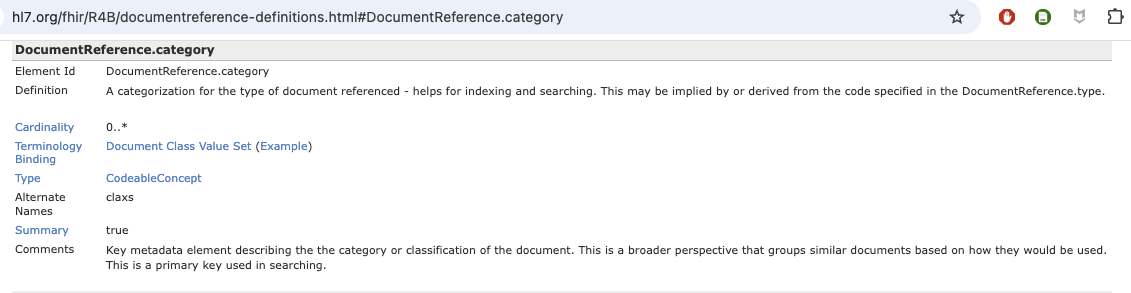

## Visualize the [CodeableConcept](https://hl7.org/fhir/R4B/datatypes.html#CodeableConcept) used in each resource

> FHIR CodeableConcepts are essential for representing and exchanging healthcare information using codes and terminologies. They ensure interoperability, provide semantic meaning, offer flexibility, and enhance human understanding of healthcare data.

In [ ]:
combined_counts = df[['research_study_identifiers', 'path', 'system',  'display', 'count']]
# Filter combined_counts to ignore rows with 'extension' in 'path'
combined_counts = combined_counts[~combined_counts['path'].str.contains('extension')]

combined_counts

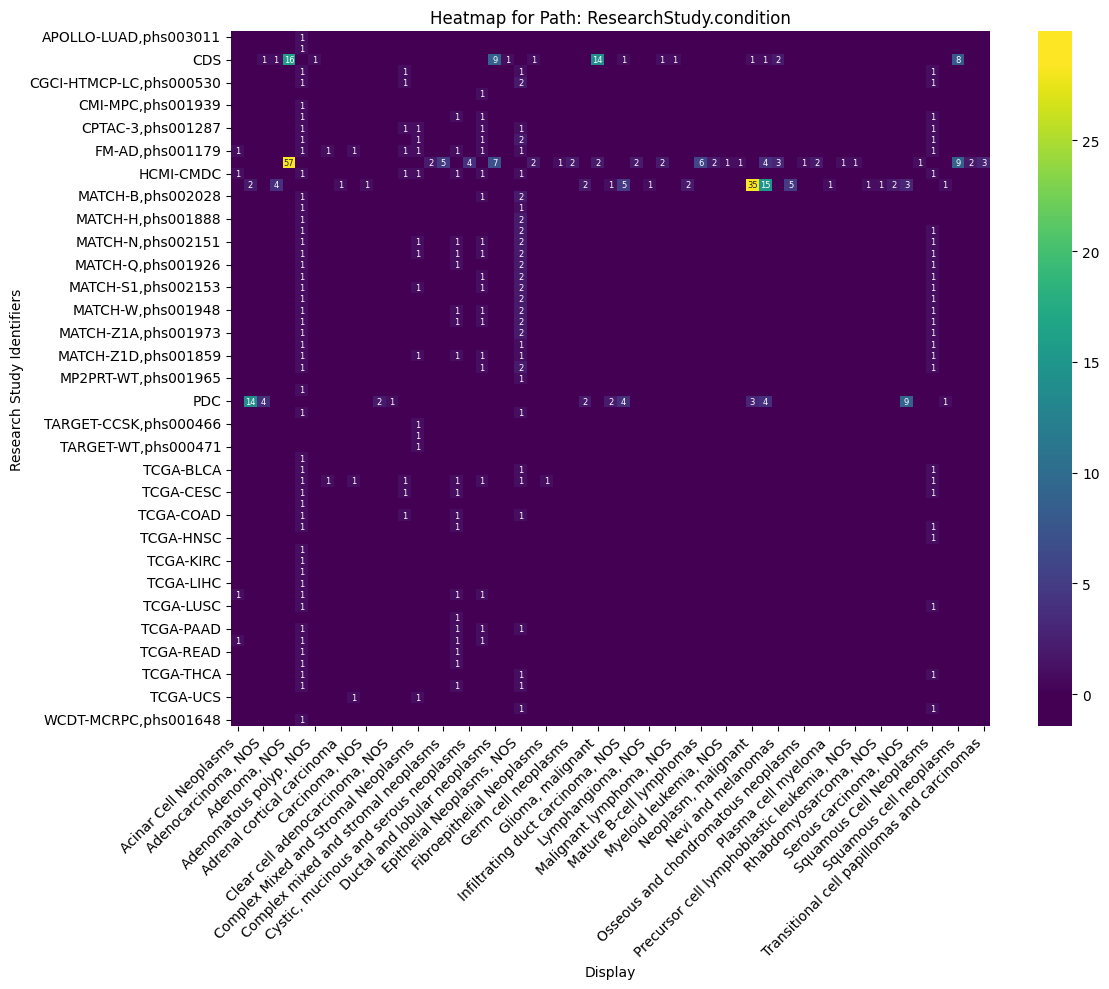

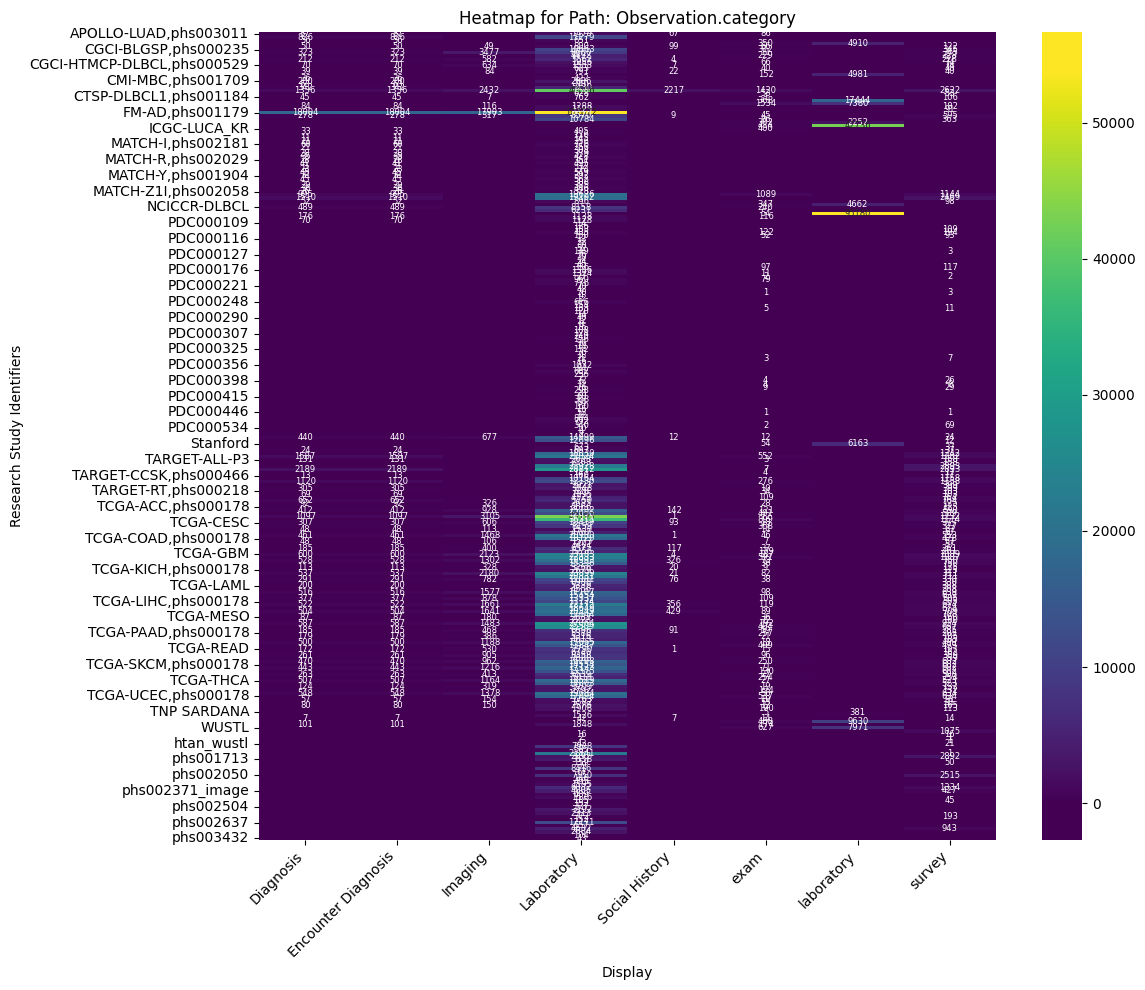

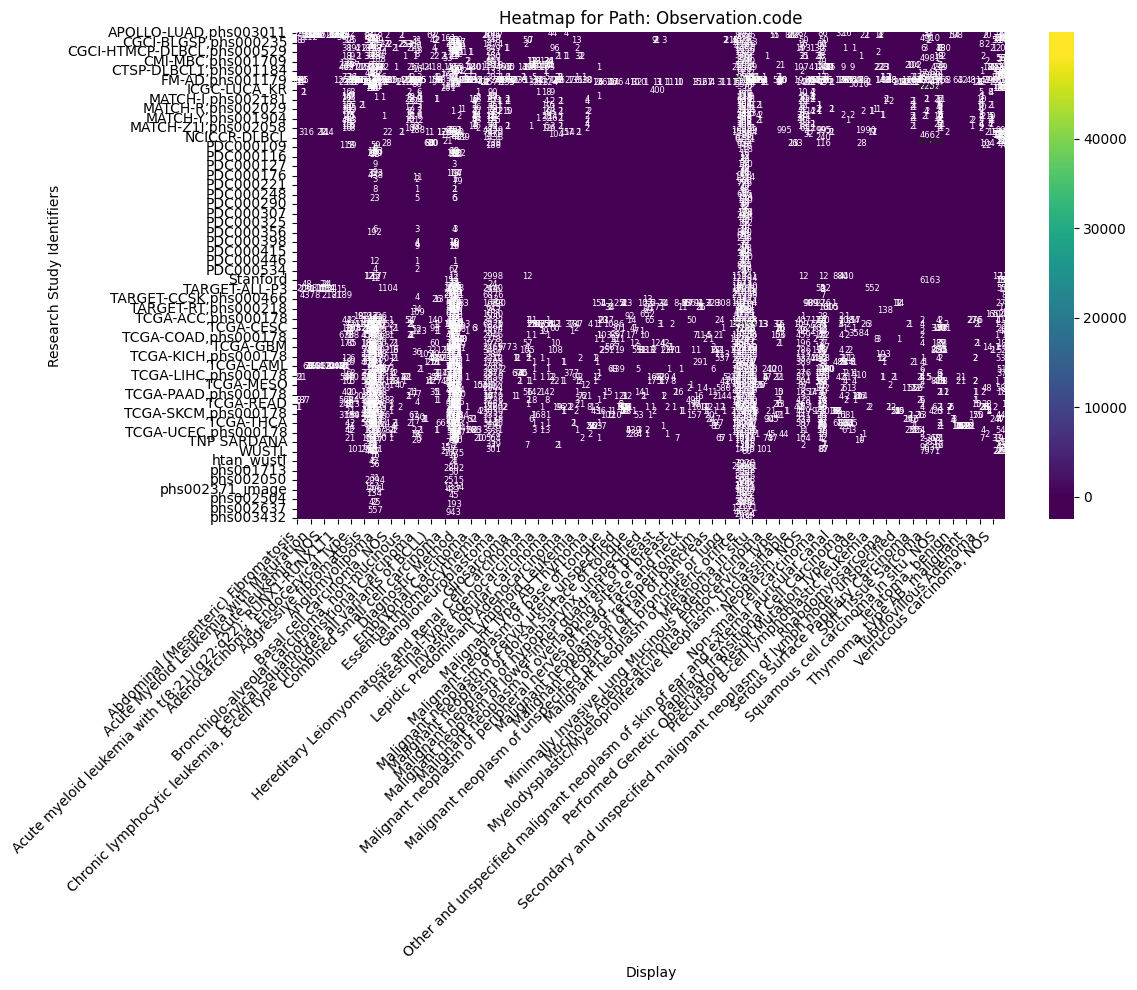

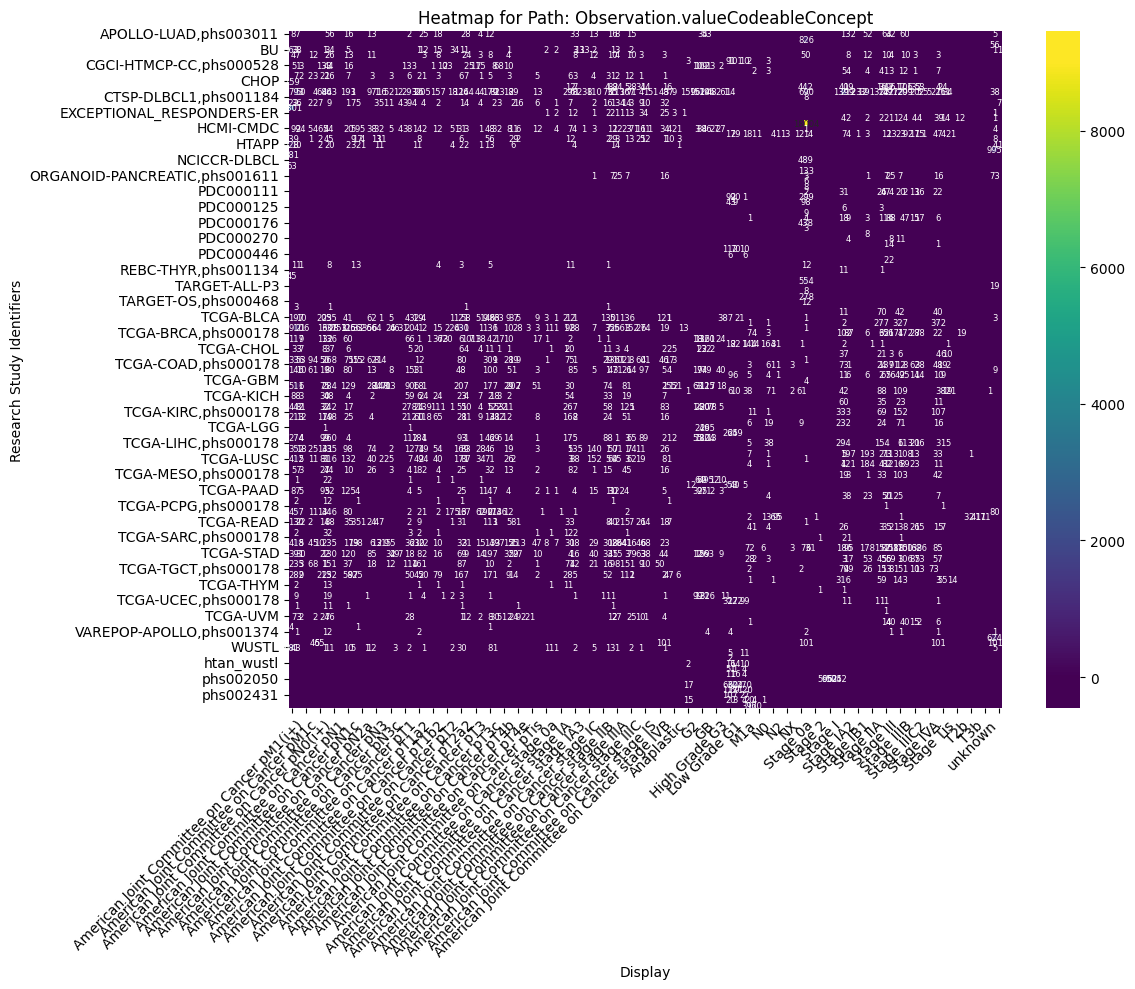

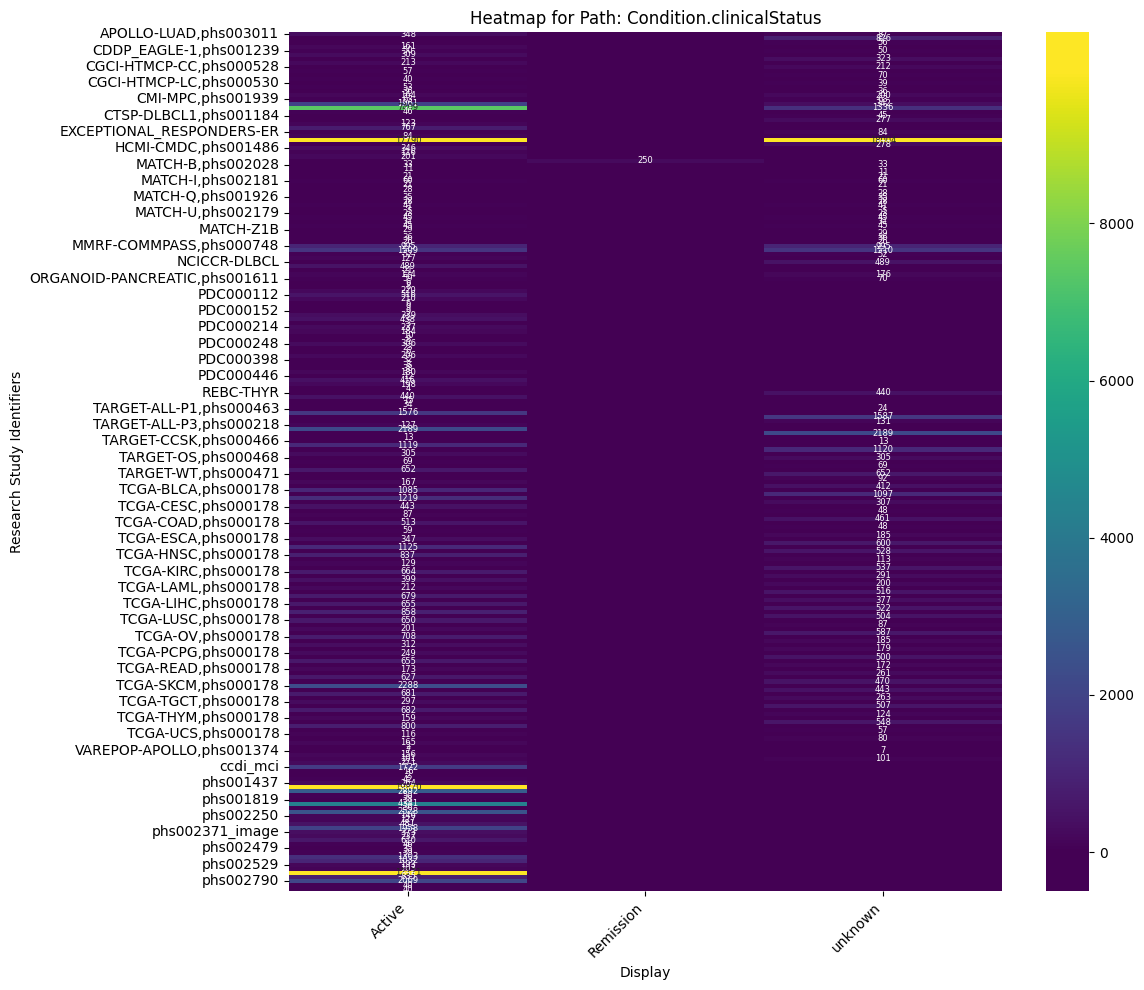

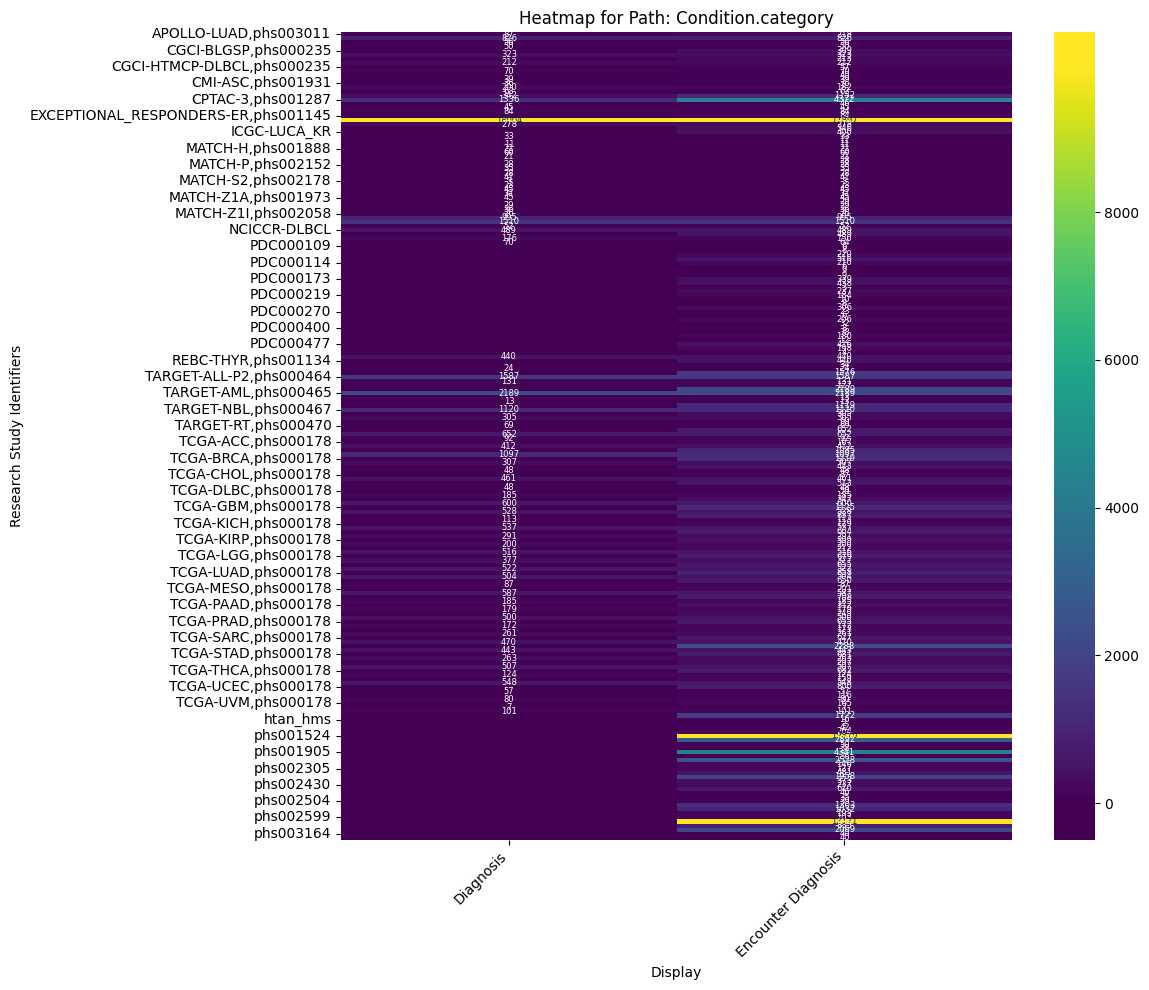

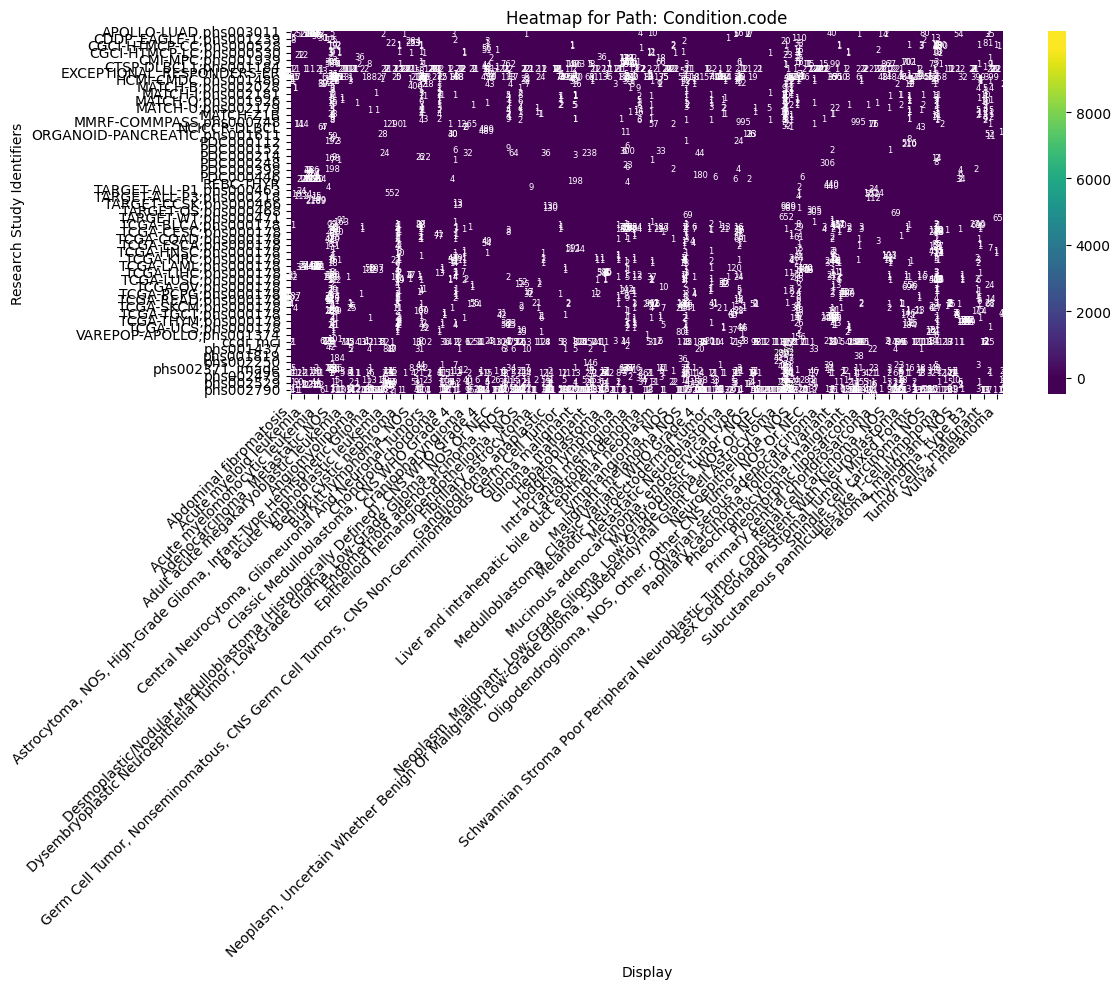

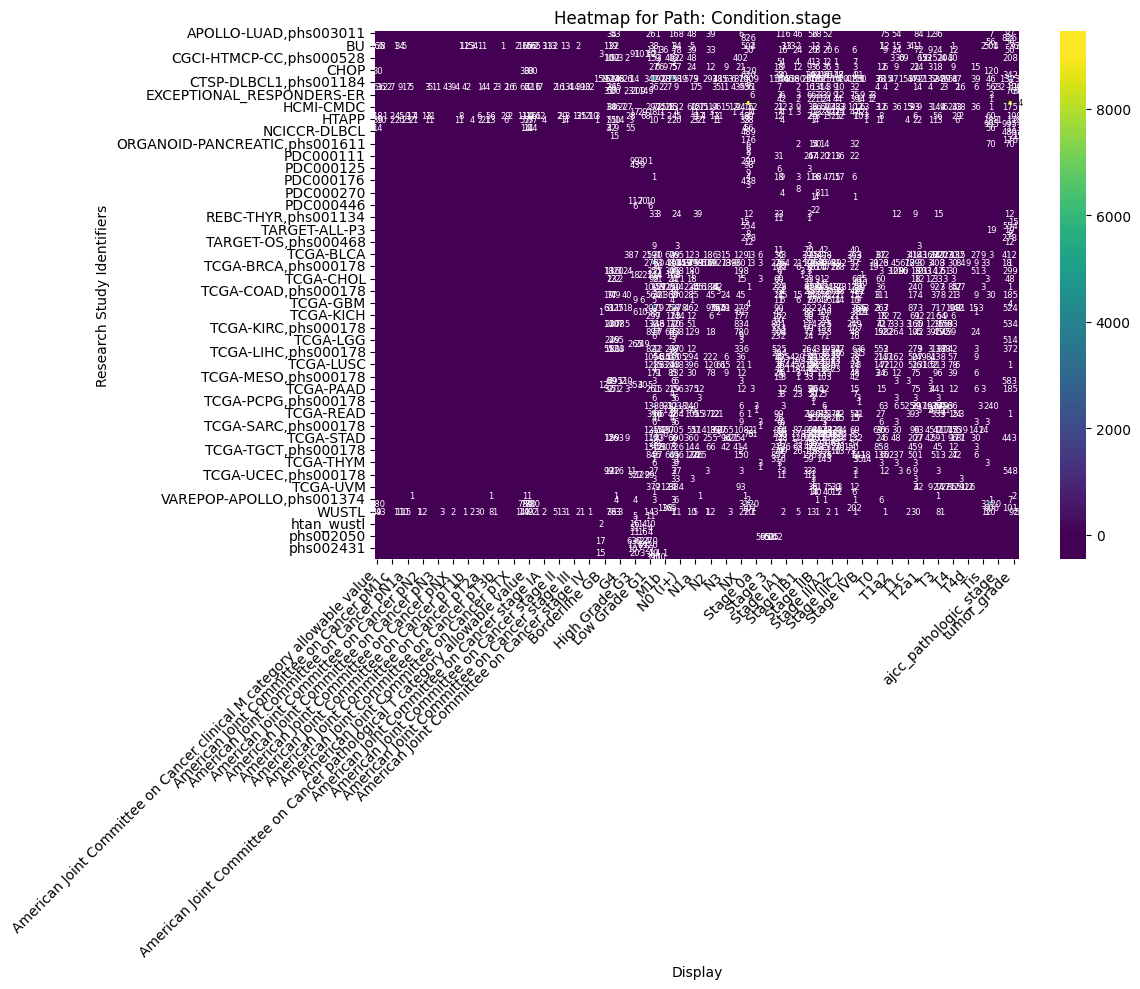

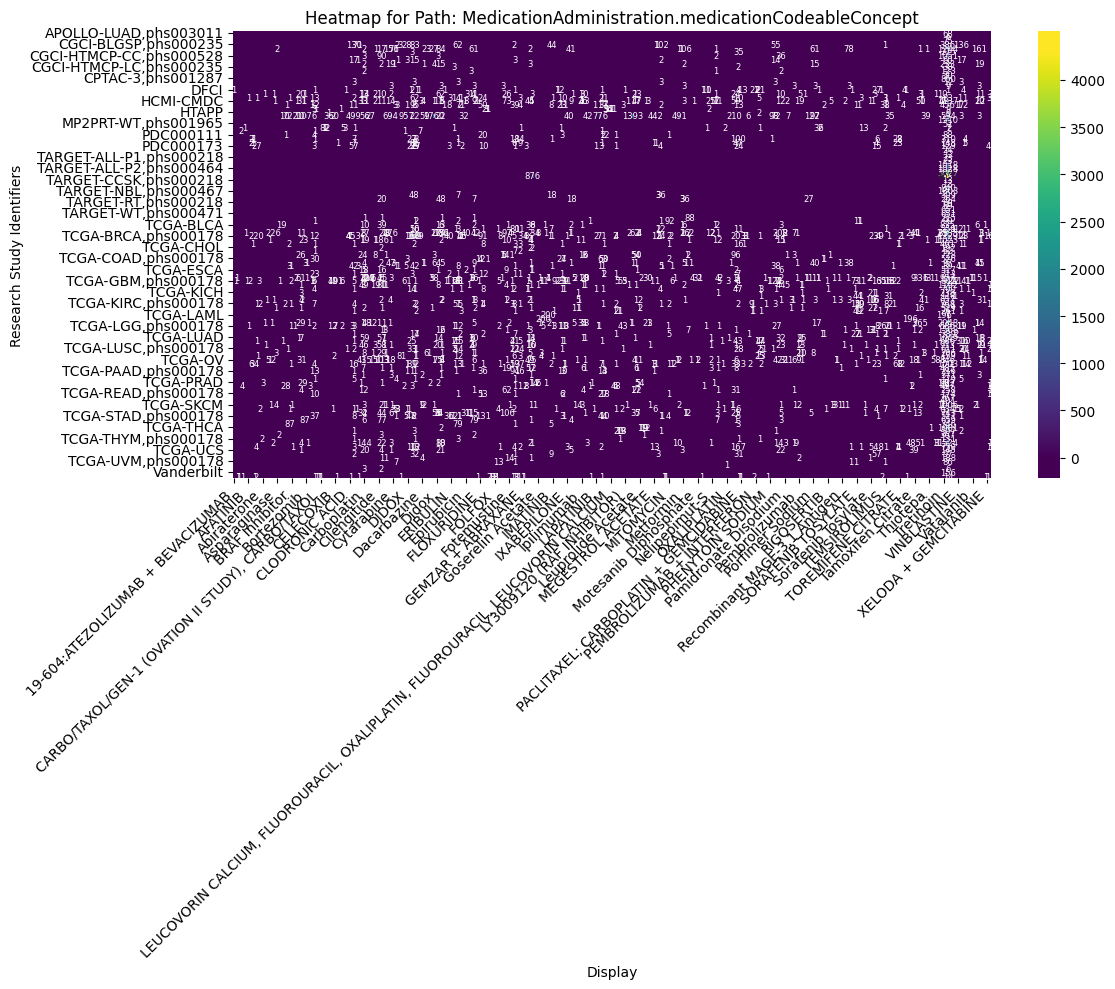

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Create heatmap for each path


# Get unique paths
unique_paths = combined_counts['path'].unique()
combined_counts = combined_counts.infer_objects(copy=False)

# Create a heatmap for each path
for path in unique_paths:
    # Filter data for the current path
    filtered_data = combined_counts[combined_counts['path'] == path]

    # Pivot the filtered data for the heatmap
    heatmap_data = filtered_data.pivot_table(index='research_study_identifiers',
                                            columns=['display'],
                                            values='count',
                                            fill_value=0.0)

    # Create the heatmap
    plt.figure(figsize=(12, 10))  # Adjust figsize as needed

    # sns.heatmap(heatmap_data, annot=True, annot_kws={"size": 6}, fmt=".0f", cmap='viridis', cbar=False)

    # Create a mask to identify zero values
    mask = heatmap_data == 0

 # Custom function to format annotations
    def heatmap_annot(val, **kwargs):
        if val == 0:  # Hide annotations for zero values
            return ""
        else:
            return f"{val:.0f}"  # Format non-zero values as integers


    # Generate heatmap with the custom annotation function
    ax = sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap='viridis',
                cbar_kws={'extend': 'both', 'extendrect': True},
                vmin=0,  # Set minimum value for color scale
                vmax=heatmap_data.max().max() / 2,  # Adjust maximum value
                annot_kws={"size": 6})  # Reduce font size


    # Apply the custom annotation function to each cell
    for text in ax.texts:
        text.set_text(heatmap_annot(float(text.get_text())))

    plt.title(f'Heatmap for Path: {path}')  # Set title with path name
    plt.xlabel('Display')
    plt.ylabel('Research Study Identifiers')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


# FHIR Extensions

A FHIR extension provides a way to add custom data elements to existing FHIR resources, enabling the representation of information that is not defined in the core FHIR specification. They allow for flexibility and extensibility within FHIR while maintaining interoperability.

The vocuabulary Observation includes a summary of these extensions

In [ ]:
# extensions with ranges
combined_extension_range_counts = df[['research_study_identifiers', 'path', 'extension_url', 'low', 'high', 'url']]
combined_extension_range_counts = combined_extension_range_counts[combined_extension_range_counts['extension_url'] != '']
combined_extension_range_counts = combined_extension_range_counts[combined_extension_range_counts['low'] != '']
combined_extension_range_counts

,research_study_identifiers,path,extension_url,low,high,url
12,ICGC-LUCA_KR,DocumentReference.extension,https://nih-ncpi.github.io/ncpi-fhir-ig-2/Stru...,365.0,206822704094.0,
3739,Cellosaurus,Patient.extension,http://hl7.org/fhir/SearchParameter/patient-ex...,1.0,94.0,
3771,1KG,DocumentReference.extension,https://nih-ncpi.github.io/ncpi-fhir-ig-2/Stru...,36047.0,16099441977.0,
3881,"BEATAML1.0-CRENOLANIB,phs001628",DocumentReference.extension,https://nih-ncpi.github.io/ncpi-fhir-ig-2/Stru...,4220.0,45589228155.0,
3886,"BEATAML1.0-CRENOLANIB,phs001628",Patient.extension,http://hl7.org/fhir/SearchParameter/patient-ex...,24.0,87.0,
...,...,...,...,...,...,...
20886,TCGA-HNSC,DocumentReference.extension,https://nih-ncpi.github.io/ncpi-fhir-ig-2/Stru...,229.0,578035949313.0,
20899,TCGA-HNSC,Patient.extension,http://hl7.org/fhir/SearchParameter/patient-ex...,19.0,89.0,
21249,TCGA-KIRC,DocumentReference.extension,https://nih-ncpi.github.io/ncpi-fhir-ig-2/Stru...,229.0,481092668932.0,
21259,TCGA-KIRC,Patient.extension,http://hl7.org/fhir/SearchParameter/patient-ex...,26.0,89.0,


In [ ]:
# extensions with codes
combined_extension_code_counts = df[['research_study_identifiers', 'path', 'extension_url', 'display', 'url', 'count']]
combined_extension_code_counts = combined_extension_code_counts[combined_extension_code_counts['extension_url'] != '']
combined_extension_code_counts = combined_extension_code_counts[combined_extension_code_counts['display'] != '']
combined_extension_code_counts

,research_study_identifiers,path,extension_url,display,url,count
13,ICGC-LUCA_KR,Patient.extension,http://hl7.org/fhir/us/core/StructureDefinitio...,M,https://google-fhir.fhir-aggregator.org/Patien...,344.0
14,ICGC-LUCA_KR,Patient.extension,http://hl7.org/fhir/us/core/StructureDefinitio...,F,https://google-fhir.fhir-aggregator.org/Patien...,56.0
41,GTEX_V10,DocumentReference.extension,https://nih-ncpi.github.io/ncpi-fhir-ig-2/Stru...,16K,https://google-fhir.fhir-aggregator.org/Docume...,1.0
42,GTEX_V10,DocumentReference.extension,https://nih-ncpi.github.io/ncpi-fhir-ig-2/Stru...,11K,https://google-fhir.fhir-aggregator.org/Docume...,1.0
43,GTEX_V10,DocumentReference.extension,https://nih-ncpi.github.io/ncpi-fhir-ig-2/Stru...,11M,https://google-fhir.fhir-aggregator.org/Docume...,1.0
...,...,...,...,...,...,...
21841,HCMI-CMDC,Patient.extension,http://hl7.org/fhir/us/core/StructureDefinitio...,black or african american,https://google-fhir.fhir-aggregator.org/Patien...,16.0
21842,HCMI-CMDC,Patient.extension,http://hl7.org/fhir/us/core/StructureDefinitio...,not hispanic or latino,https://google-fhir.fhir-aggregator.org/Patien...,158.0
21843,HCMI-CMDC,Patient.extension,http://hl7.org/fhir/us/core/StructureDefinitio...,not reported,https://google-fhir.fhir-aggregator.org/Patien...,42.0
21844,HCMI-CMDC,Patient.extension,http://hl7.org/fhir/us/core/StructureDefinitio...,Unknown,https://google-fhir.fhir-aggregator.org/Patien...,67.0


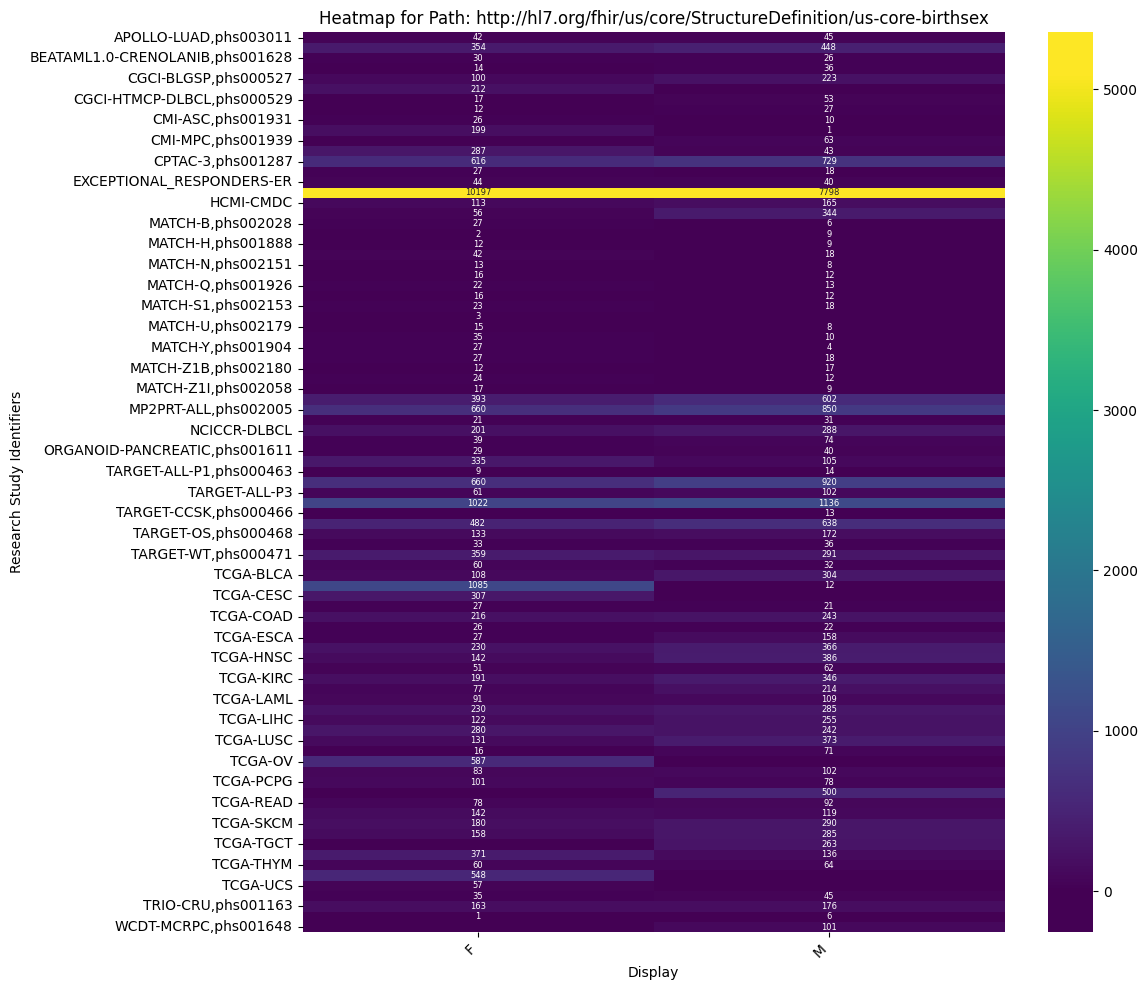

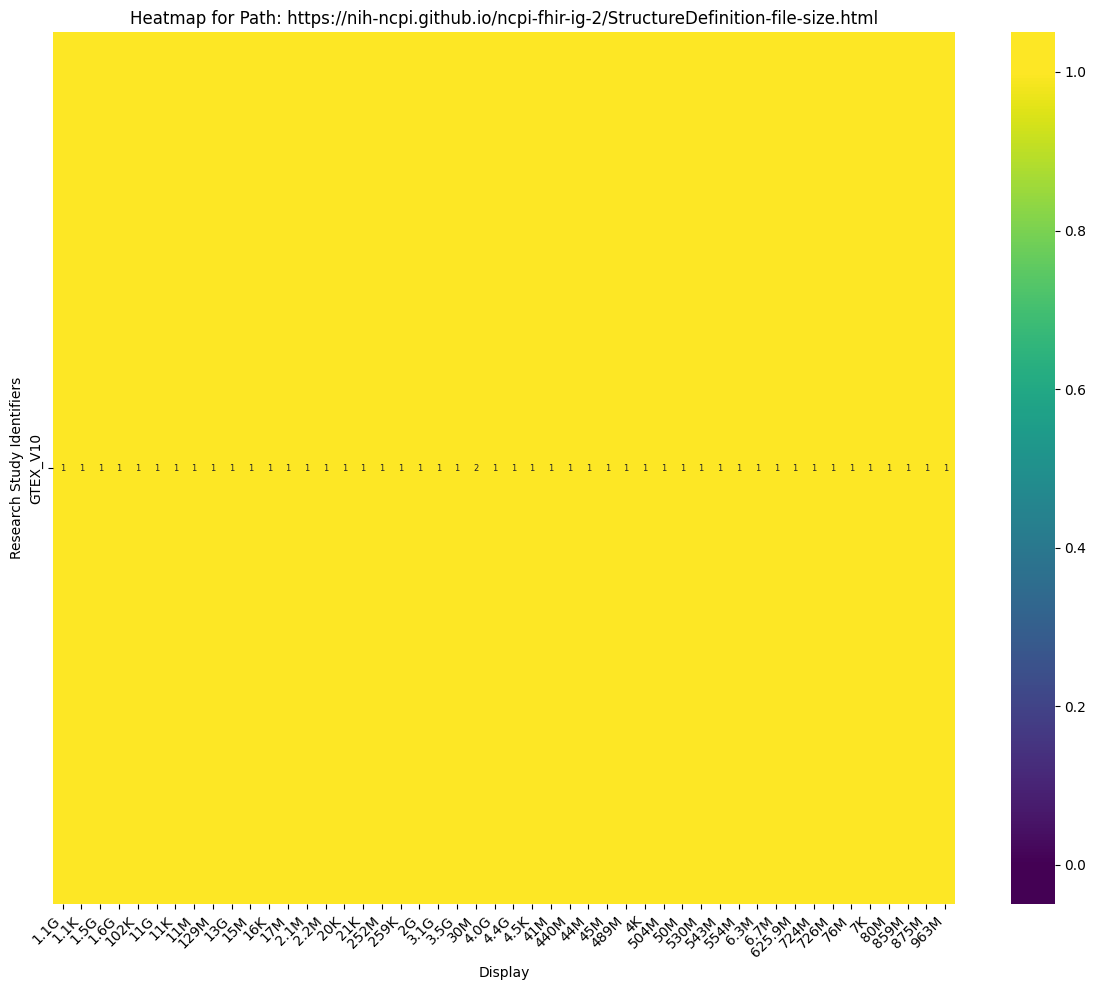

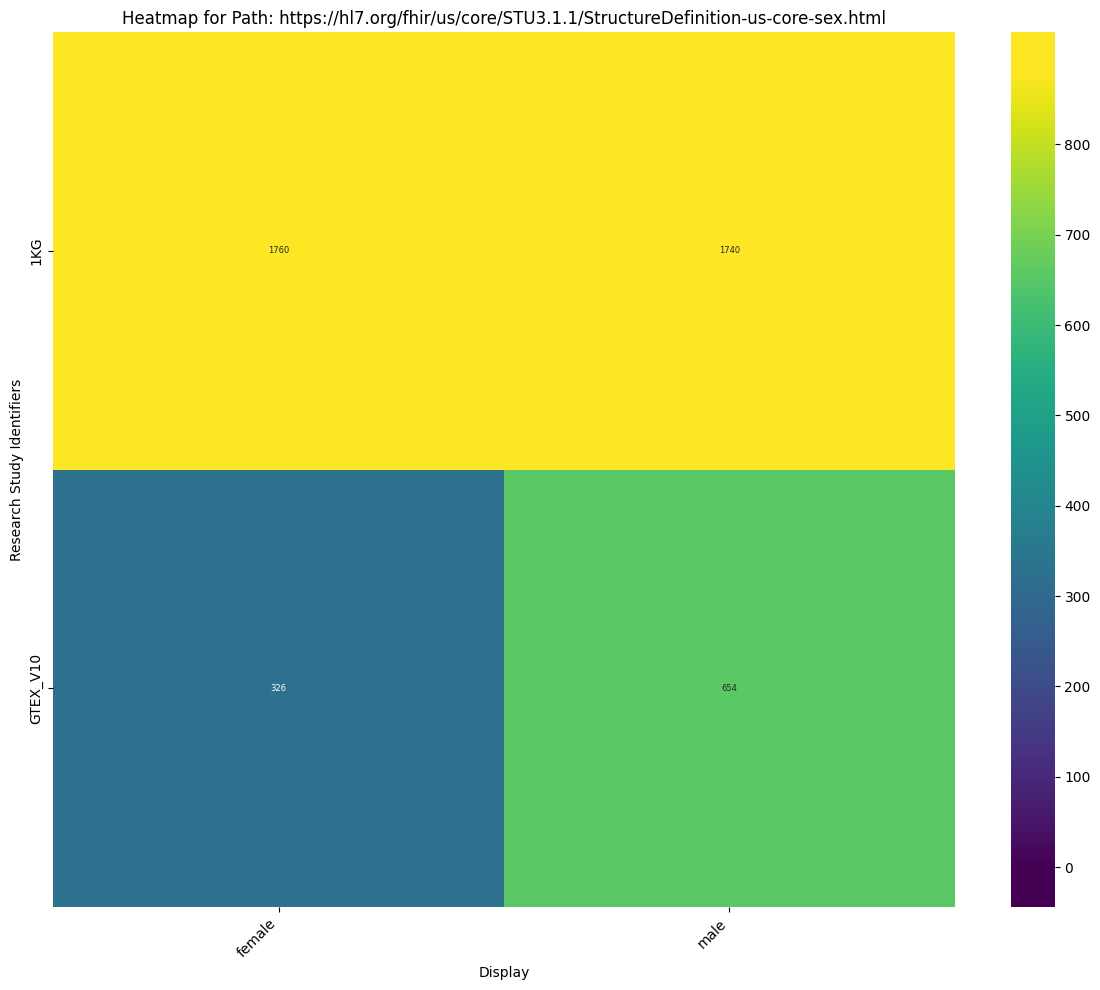

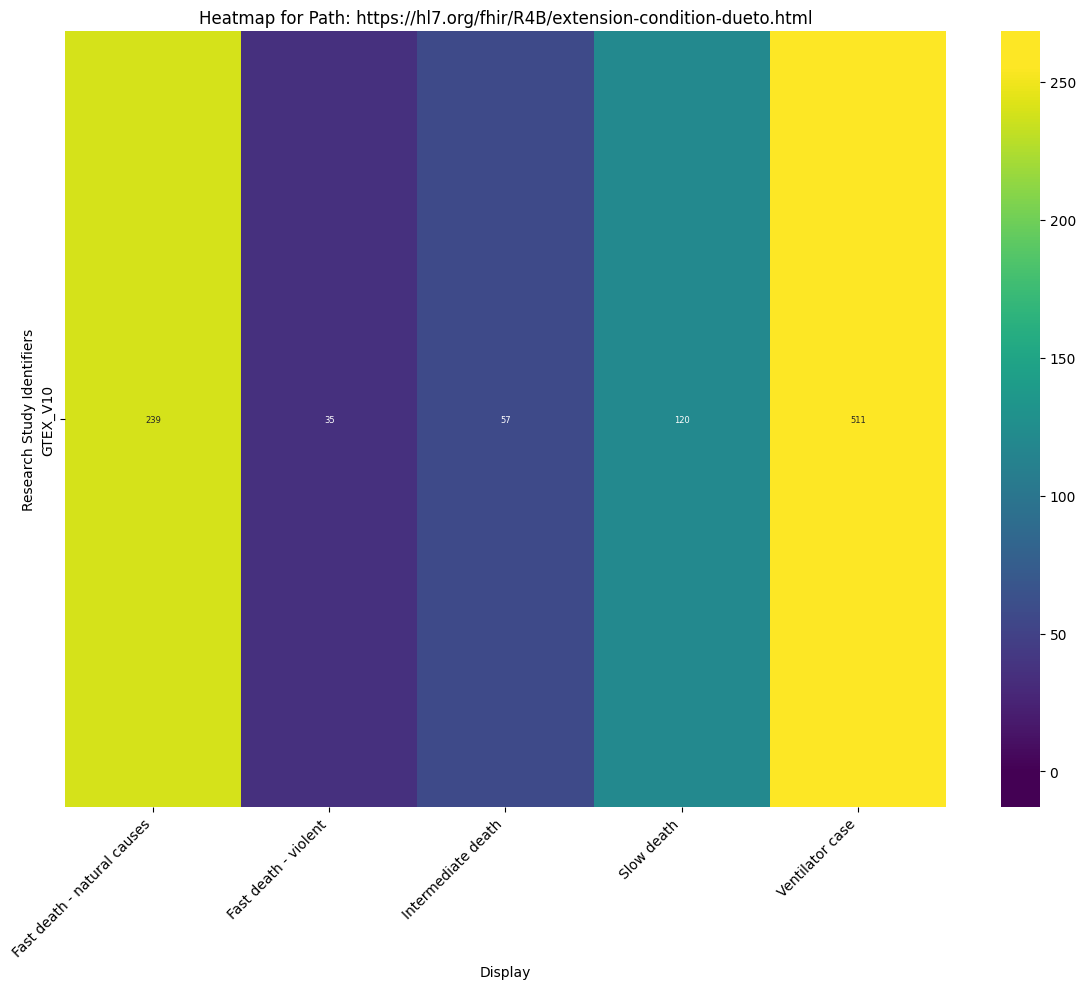

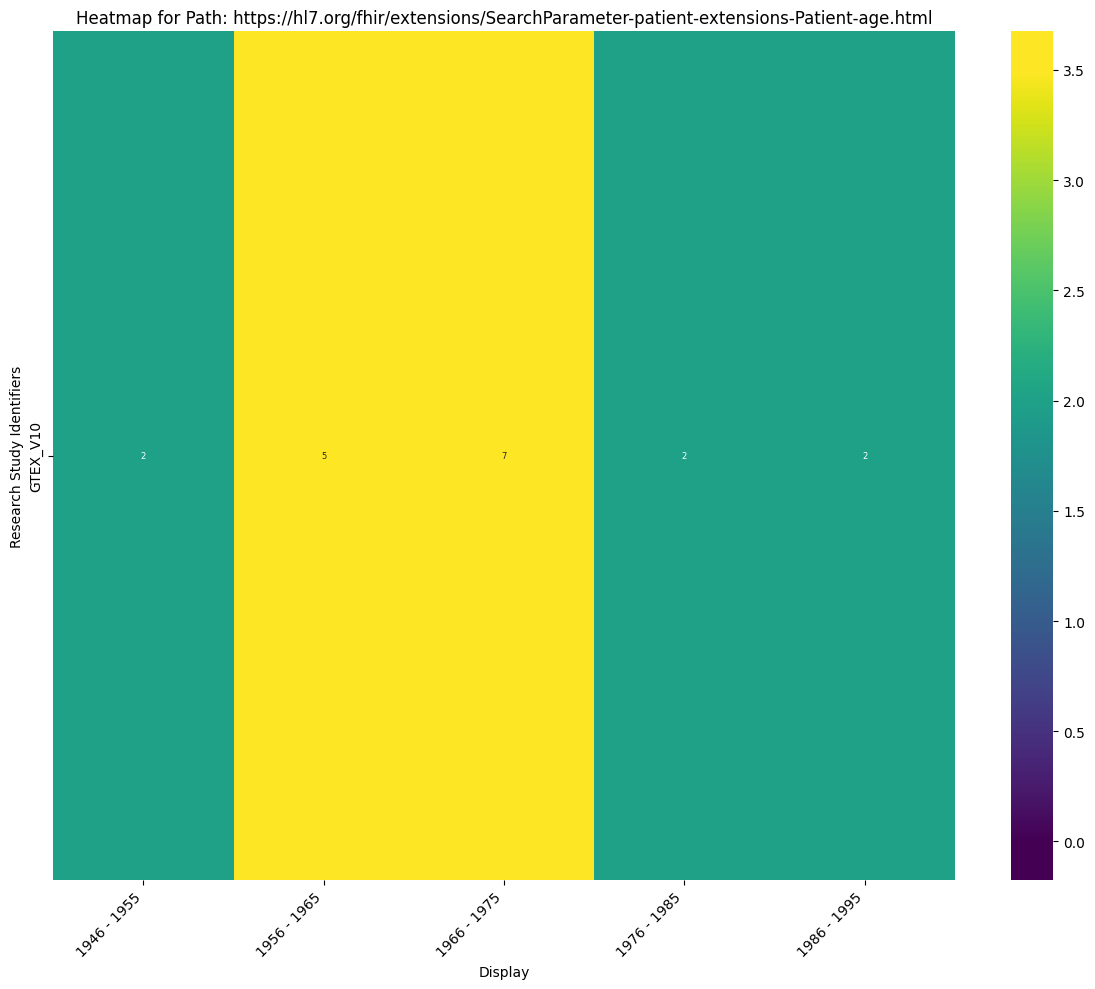

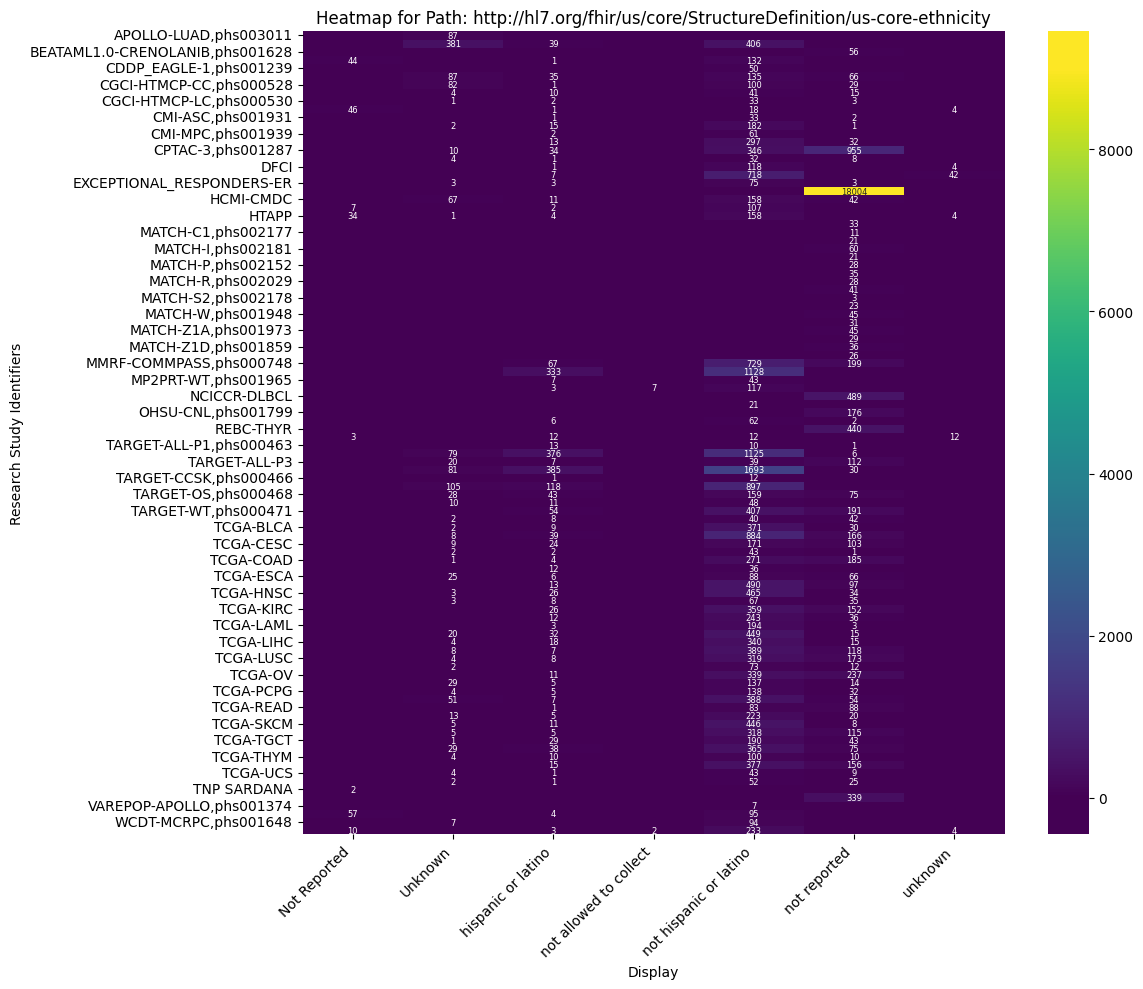

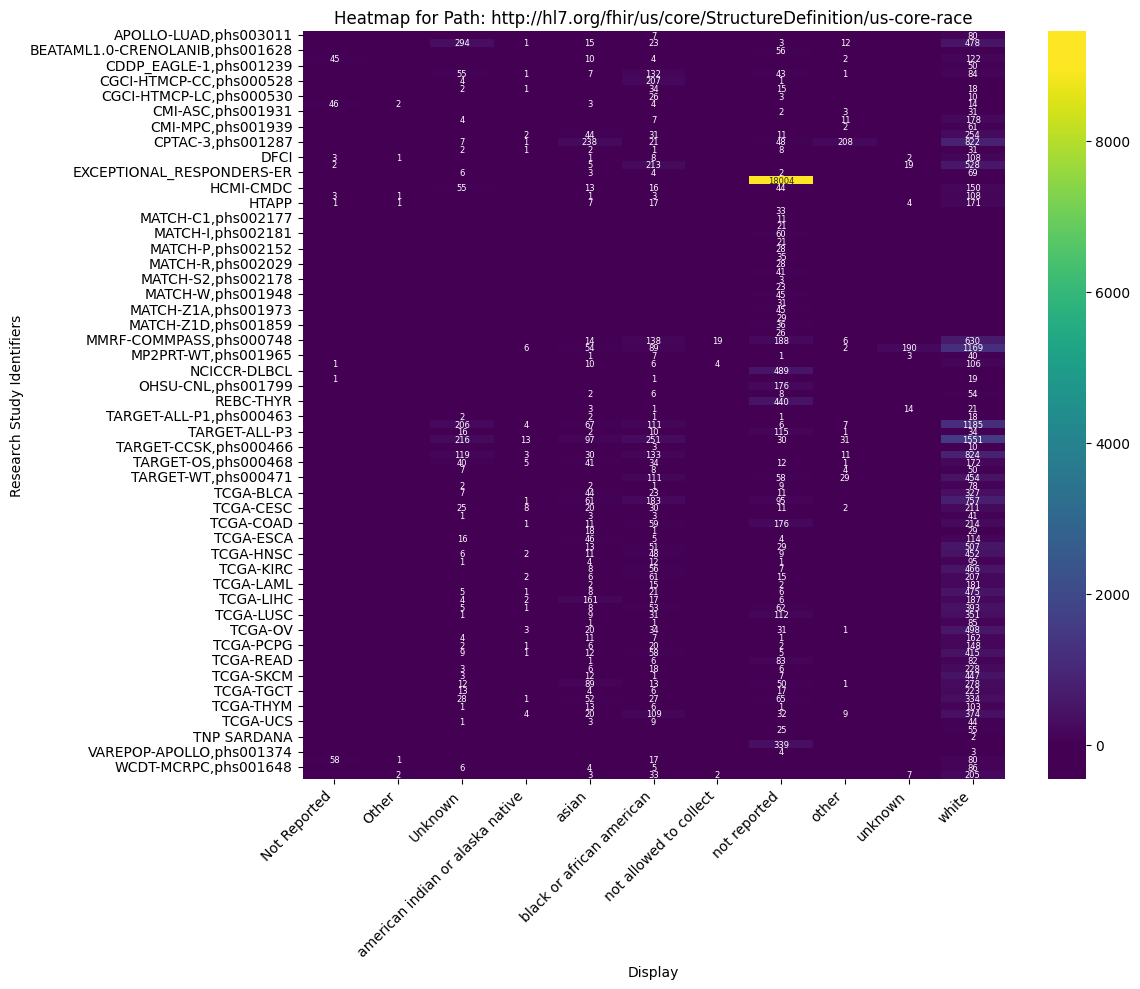

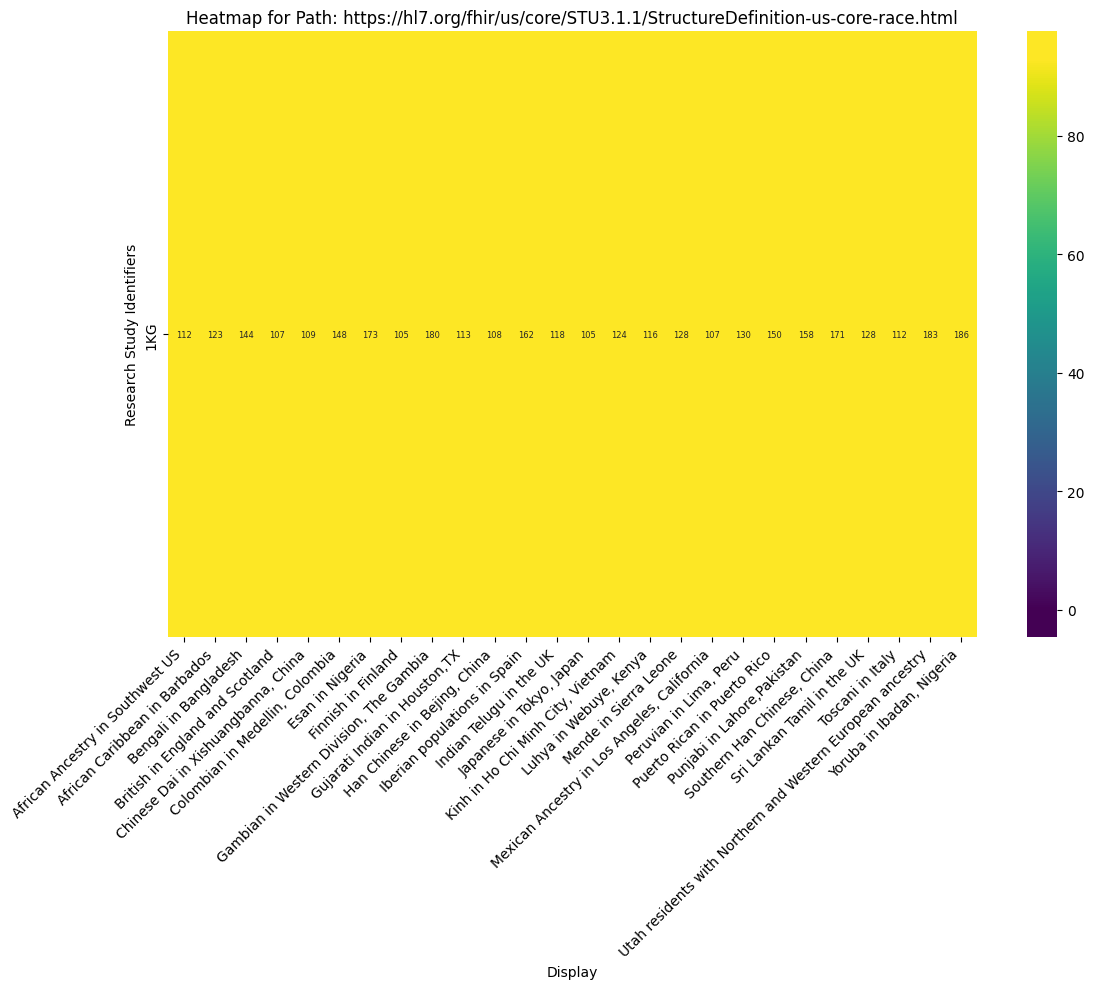

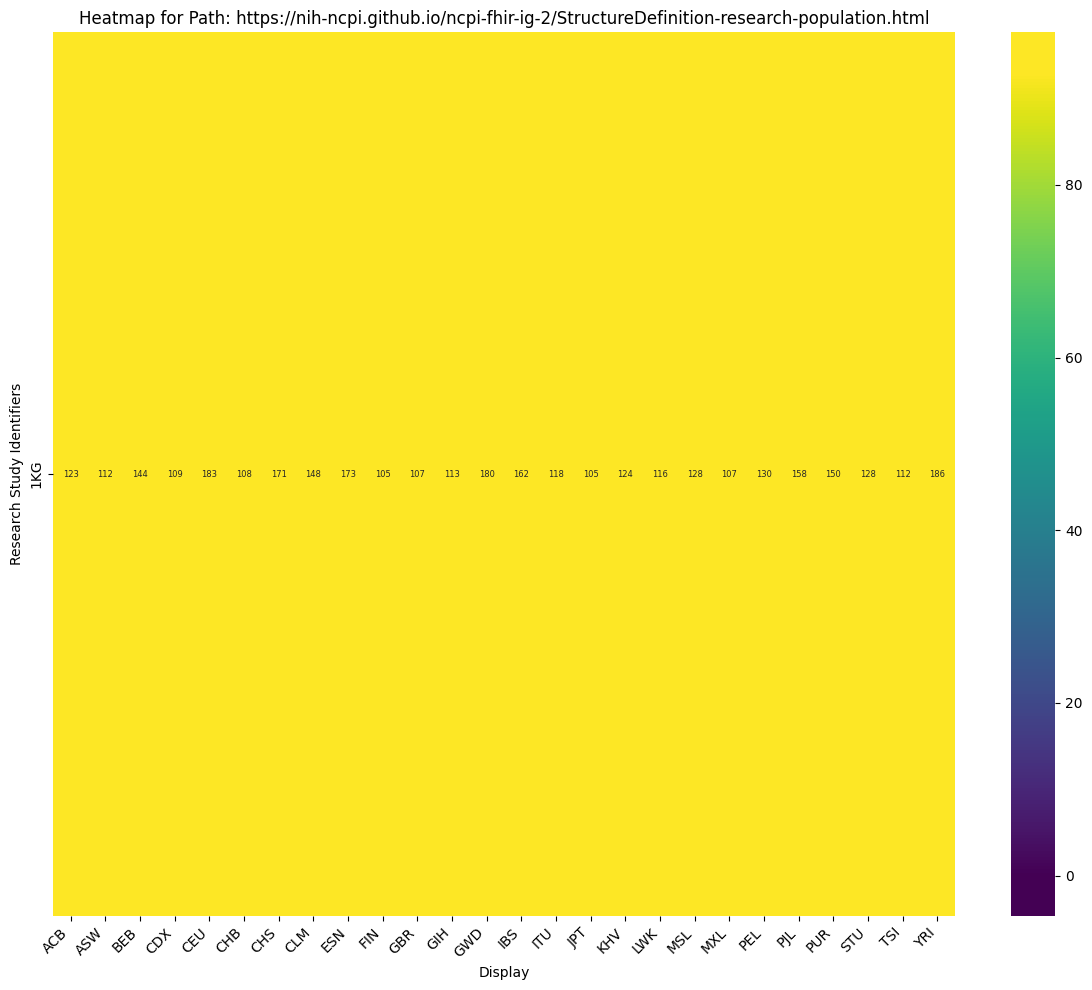

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Create heatmap for each extension

# Get unique extensions
extension_urls = combined_extension_code_counts['extension_url'].unique()
combined_extension_code_counts = combined_extension_code_counts.infer_objects(copy=False)

for extension_url in extension_urls:
    # Filter data for the current extension
    filtered_data = combined_extension_code_counts[combined_extension_code_counts['extension_url'] == extension_url]

    # Pivot the filtered data for the heatmap
    heatmap_data = filtered_data.pivot_table(index='research_study_identifiers',
                                            columns=['display'],
                                            values='count',
                                            fill_value=0.0)

    # Create the heatmap
    plt.figure(figsize=(12, 10))  # Adjust figsize as needed

    # sns.heatmap(heatmap_data, annot=True, annot_kws={"size": 6}, fmt=".0f", cmap='viridis', cbar=False)

    # Create a mask to identify zero values
    mask = heatmap_data == 0

 # Custom function to format annotations
    def heatmap_annot(val, **kwargs):
        if val == 0:  # Hide annotations for zero values
            return ""
        else:
            return f"{val:.0f}"  # Format non-zero values as integers


    # Generate heatmap with the custom annotation function
    ax = sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap='viridis',
                cbar_kws={'extend': 'both', 'extendrect': True},
                vmin=0,  # Set minimum value for color scale
                vmax=heatmap_data.max().max() / 2,  # Adjust maximum value
                annot_kws={"size": 6})  # Reduce font size


    # Apply the custom annotation function to each cell
    for text in ax.texts:
        text.set_text(heatmap_annot(float(text.get_text())))

    plt.title(f'Heatmap for Path: {extension_url}')  # Set title with path name
    plt.xlabel('Display')
    plt.ylabel('Research Study Identifiers')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Explore 1000 Genomes
Lets narrow the search to a specific Project

In [ ]:
scratch_df = df[df['research_study_identifiers'].str.contains('1KG')]
scratch_df

,research_study_identifiers,path,documentation,code,display,system,extension_url,count,low,high,url,research_study_title,research_study_description,observation,research_study
3740,1KG,ServiceRequest.category,https://hl7.org/fhir/R4B/servicerequest-defini...,108252007,Laboratory procedure,http://snomed.info/sct,,1.0,,,https://google-fhir.fhir-aggregator.org/Servic...,1000 Genomes Project Sample Metadata,,Observation/db717d0f-1ca1-5c2f-b01c-17ee8c73fbf6,ResearchStudy/4502d1f5-5275-5be7-9942-21f7fb8a...
3741,1KG,ServiceRequest.code,https://hl7.org/fhir/R4B/servicerequest-defini...,15220000,Laboratory test,http://snomed.info/sct,,1.0,,,https://google-fhir.fhir-aggregator.org/Servic...,1000 Genomes Project Sample Metadata,,Observation/db717d0f-1ca1-5c2f-b01c-17ee8c73fbf6,ResearchStudy/4502d1f5-5275-5be7-9942-21f7fb8a...
3742,1KG,DocumentReference.type,https://hl7.org/fhir/R4B/documentreference-def...,VCF,VCF,https://ftp.1000genomes.ebi.ac.uk/data_format,,46.0,,,https://google-fhir.fhir-aggregator.org/Docume...,1000 Genomes Project Sample Metadata,,Observation/db717d0f-1ca1-5c2f-b01c-17ee8c73fbf6,ResearchStudy/4502d1f5-5275-5be7-9942-21f7fb8a...
3743,1KG,DocumentReference.type,https://hl7.org/fhir/R4B/documentreference-def...,NEW,NEW,https://ftp.1000genomes.ebi.ac.uk/data_format,,2.0,,,https://google-fhir.fhir-aggregator.org/Docume...,1000 Genomes Project Sample Metadata,,Observation/db717d0f-1ca1-5c2f-b01c-17ee8c73fbf6,ResearchStudy/4502d1f5-5275-5be7-9942-21f7fb8a...
3744,1KG,DocumentReference.category,https://hl7.org/fhir/R4B/documentreference-def...,1,Chromosome 1,https://ftp.1000genomes.ebi.ac.uk/chromosome,,2.0,,,https://google-fhir.fhir-aggregator.org/Docume...,1000 Genomes Project Sample Metadata,,Observation/db717d0f-1ca1-5c2f-b01c-17ee8c73fbf6,ResearchStudy/4502d1f5-5275-5be7-9942-21f7fb8a...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3821,1KG,Patient.extension,https://hl7.org/fhir/R4B/patient-definitions.h...,LWK,LWK,,https://nih-ncpi.github.io/ncpi-fhir-ig-2/Stru...,116.0,,,https://google-fhir.fhir-aggregator.org/Patien...,1000 Genomes Project Sample Metadata,,Observation/db717d0f-1ca1-5c2f-b01c-17ee8c73fbf6,ResearchStudy/4502d1f5-5275-5be7-9942-21f7fb8a...
3822,1KG,Patient.extension,https://hl7.org/fhir/R4B/patient-definitions.h...,ASW,ASW,,https://nih-ncpi.github.io/ncpi-fhir-ig-2/Stru...,112.0,,,https://google-fhir.fhir-aggregator.org/Patien...,1000 Genomes Project Sample Metadata,,Observation/db717d0f-1ca1-5c2f-b01c-17ee8c73fbf6,ResearchStudy/4502d1f5-5275-5be7-9942-21f7fb8a...
3823,1KG,Patient.extension,https://hl7.org/fhir/R4B/patient-definitions.h...,MXL,MXL,,https://nih-ncpi.github.io/ncpi-fhir-ig-2/Stru...,107.0,,,https://google-fhir.fhir-aggregator.org/Patien...,1000 Genomes Project Sample Metadata,,Observation/db717d0f-1ca1-5c2f-b01c-17ee8c73fbf6,ResearchStudy/4502d1f5-5275-5be7-9942-21f7fb8a...
3824,1KG,Patient.extension,https://hl7.org/fhir/R4B/patient-definitions.h...,TSI,TSI,,https://nih-ncpi.github.io/ncpi-fhir-ig-2/Stru...,112.0,,,https://google-fhir.fhir-aggregator.org/Patien...,1000 Genomes Project Sample Metadata,,Observation/db717d0f-1ca1-5c2f-b01c-17ee8c73fbf6,ResearchStudy/4502d1f5-5275-5be7-9942-21f7fb8a...


# Explore a Condition

## List the conditons found in each ResearchStudy

In [ ]:
scratch_df = df[df['path'].str.contains('Condition.code')]
scratch_df

,research_study_identifiers,path,documentation,code,display,system,extension_url,count,low,high,url,research_study_title,research_study_description,observation,research_study
11,ICGC-LUCA_KR,Condition.code,https://hl7.org/fhir/R4B/condition-definitions...,C15.5,C15.5,https://terminology.hl7.org/5.1.0/NamingSystem...,,400.0,,,https://google-fhir.fhir-aggregator.org/Condit...,,ICGC DCC & Argo Personalised Genomic Character...,Observation/4fc6bcaa-bb07-51e9-99b2-a85f679d81ab,ResearchStudy/92f949c7-4244-5218-8569-59707365...
230,TNP SARDANA,Condition.code,https://hl7.org/fhir/R4B/condition-definitions...,Mucous adenocarcinoma,Mucous adenocarcinoma,https://data.humantumoratlas.org,,1.0,,,https://google-fhir.fhir-aggregator.org/Condit...,,,Observation/e6d6c1dc-d227-5b29-ab6f-3c4102589475,ResearchStudy/b7015858-983c-5e51-bcd6-af788edd...
231,TNP SARDANA,Condition.code,https://hl7.org/fhir/R4B/condition-definitions...,Not Reported,Not Reported,https://data.humantumoratlas.org,,1.0,,,https://google-fhir.fhir-aggregator.org/Condit...,,,Observation/e6d6c1dc-d227-5b29-ab6f-3c4102589475,ResearchStudy/b7015858-983c-5e51-bcd6-af788edd...
534,HTAPP,Condition.code,https://hl7.org/fhir/R4B/condition-definitions...,Lobular and ductal carcinoma,Lobular and ductal carcinoma,https://data.humantumoratlas.org,,9.0,,,https://google-fhir.fhir-aggregator.org/Condit...,,,Observation/165e6f12-8c34-5cec-9964-57222cc93b42,ResearchStudy/64eafc92-6a65-5fb6-9d0e-15778b9a...
535,HTAPP,Condition.code,https://hl7.org/fhir/R4B/condition-definitions...,Ductal carcinoma NOS,Ductal carcinoma NOS,https://data.humantumoratlas.org,,43.0,,,https://google-fhir.fhir-aggregator.org/Condit...,,,Observation/165e6f12-8c34-5cec-9964-57222cc93b42,ResearchStudy/64eafc92-6a65-5fb6-9d0e-15778b9a...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21671,HCMI-CMDC,Condition.code,https://hl7.org/fhir/R4B/condition-definitions...,Serous surface papillary carcinoma,Serous surface papillary carcinoma,https://gdc.cancer.gov/primary_diagnosis,,1.0,,,https://google-fhir.fhir-aggregator.org/Condit...,NCI Cancer Model Development for the Human Can...,,Observation/7314f7c1-5afb-5722-9293-8c97cfe9f0ea,ResearchStudy/e2d5a499-d435-5e37-93ef-0a39dfcb...
21672,HCMI-CMDC,Condition.code,https://hl7.org/fhir/R4B/condition-definitions...,"Carcinosarcoma, NOS","Carcinosarcoma, NOS",https://gdc.cancer.gov/primary_diagnosis,,1.0,,,https://google-fhir.fhir-aggregator.org/Condit...,NCI Cancer Model Development for the Human Can...,,Observation/7314f7c1-5afb-5722-9293-8c97cfe9f0ea,ResearchStudy/e2d5a499-d435-5e37-93ef-0a39dfcb...
21673,HCMI-CMDC,Condition.code,https://hl7.org/fhir/R4B/condition-definitions...,"Serous cystadenocarcinoma, NOS","Serous cystadenocarcinoma, NOS",https://gdc.cancer.gov/primary_diagnosis,,1.0,,,https://google-fhir.fhir-aggregator.org/Condit...,NCI Cancer Model Development for the Human Can...,,Observation/7314f7c1-5afb-5722-9293-8c97cfe9f0ea,ResearchStudy/e2d5a499-d435-5e37-93ef-0a39dfcb...
21674,HCMI-CMDC,Condition.code,https://hl7.org/fhir/R4B/condition-definitions...,Abdominal fibromatosis,Abdominal fibromatosis,https://gdc.cancer.gov/primary_diagnosis,,1.0,,,https://google-fhir.fhir-aggregator.org/Condit...,NCI Cancer Model Development for the Human Can...,,Observation/7314f7c1-5afb-5722-9293-8c97cfe9f0ea,ResearchStudy/e2d5a499-d435-5e37-93ef-0a39dfcb...


## Find a given Condition: Neuroblastoma
1. FHIR Query: The curl command sends the FHIR query to the server.
2. Data Extraction and Formatting: jq extracts the system, code, and display information from the coding elements within each Condition resource and formats them as TSV.
3. Sorting: The output is piped to sort to arrange the entries alphabetically.
4. Deduplication: The -u option in sort removes any duplicate entries, leaving only unique combinations of system, code, and display.
5. Output: The final result is a sorted and deduplicated list of coding information for conditions starting with "Adenocarcinoma," presented as TSV.

In [ ]:
!curl -s $FHIR_BASE'/Condition?code:text=Neuroblastoma&_count=1000&_total=accurate&_elements=subject,extension,code'  | jq -rc ' .entry[] | .resource | .code.coding[] | [.system, .code, .display] | @tsv' | sort | uniq -c
#| jq -rc '.entry[] | .resource | [.subject.reference, (.extension[] | .valueReference.reference)] '


      2 https://data.humantumoratlas.org	Central neuroblastoma	Central neuroblastoma
      3 https://data.humantumoratlas.org	Neuroblastoma NOS	Neuroblastoma NOS
    995 https://gdc.cancer.gov/primary_diagnosis	Neuroblastoma, NOS	Neuroblastoma, NOS
